# Chapitre 4 — EDA diagnostique et qualité des données

**Durée estimée : 8-10 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Distinguer** l'EDA diagnostique (trouver les problèmes) de l'EDA analytique (comprendre les patterns)
2. **Évaluer** la qualité des données selon les 6 dimensions standardisées
3. **Détecter** les valeurs manquantes, doublons et outliers avec les outils pandas appropriés
4. **Documenter** les problèmes identifiés dans une checklist de qualité priorisée

---

### ✍️ Exercice 4.7 : Dashboard de diagnostic (20 min)

Objectif

Visualiser rapidement les distributions et anomalies dans les données brutes avant tout nettoyage ou analyse.
	•	Identifier : valeurs manquantes, outliers, distributions bizarres.
	•	Utiliser : histogrammes, barplots, boxplots, scatterplots.

#### 1️⃣ Préparer les librairies et données

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Créer un exemple de dataset
np.random.seed(42)
df_viz = pd.DataFrame({
    'age': np.concatenate([np.random.randint(18, 70, 97), [150, -5, 200]]),
    'salaire': np.concatenate([np.random.normal(50000, 15000, 95), [np.nan]*5]),
    'categorie': np.random.choice(['A','B','C'], 100)
})

print("Données préparées pour la visualisation")
df_viz.head()

# Explications :
# np.random.seed(42) → fixe le hasard pour que les résultats soient reproductibles.
# np.random.randint et np.random.normal → génèrent des valeurs aléatoires.
# np.nan → représente les valeurs manquantes.
# On ne nettoie pas ici, car l’objectif est le diagnostic.

Données préparées pour la visualisation


,age,salaire,categorie
0,56,54861.259541,A
1,69,44223.765794,A
2,46,39846.169995,C
3,32,59175.144333,C
4,60,65464.992837,C


#### 2️⃣ Créer une figure avec plusieurs graphiques

On veut âge, salaire et catégories côte à côte pour un diagnostic rapide.

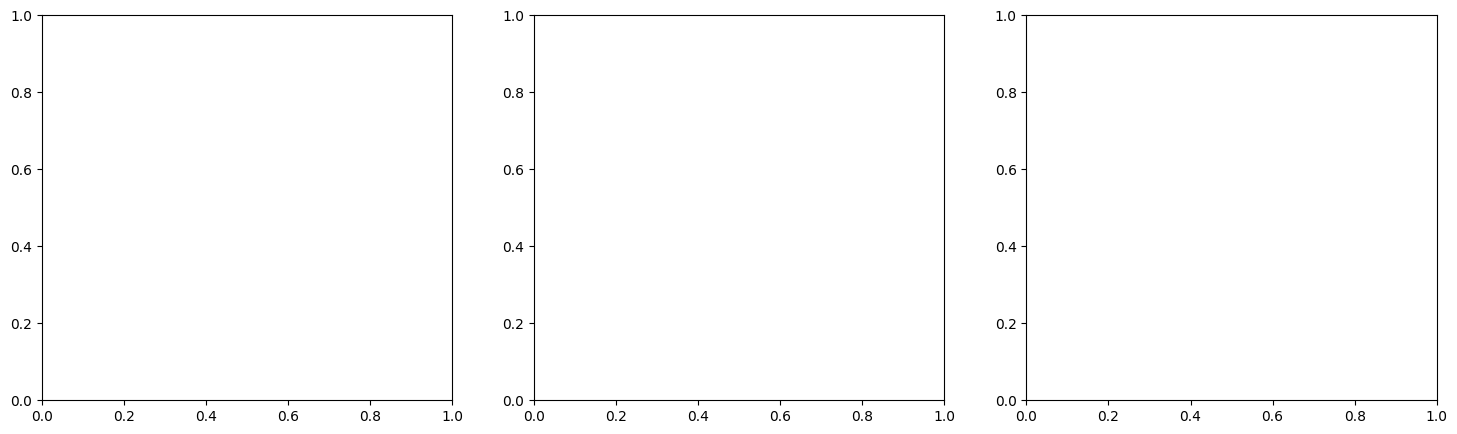

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))  # 1 ligne, 3 colonnes, taille de la figure

# Explications :
# fig → objet figure global
# axes → liste de sous-graphiques (axes)
# figsize → taille de la figure en pouces (largeur, hauteur)

In [27]:
# Histogramme des âges
axes[0].hist(df_viz['age'].dropna(), bins=15, edgecolor='black', color='salmon')
axes[0].set_title('Distribution des âges')
axes[0].set_xlabel('Âge')
axes[0].set_ylabel('Nombre de personnes')

# Explications :
# hist() → trace un histogramme
# bins=15 → nombre de barres
# edgecolor='black' → contour des barres
# axes[0].set_title() → titre pour ce sous-graphique
# Labels pour axes X et Y

Text(4.444444444444452, 0.5, 'Nombre de personnes')

In [28]:
# Histogramme des salaires
axes[1].hist(df_viz['salaire'].dropna(), bins=15, edgecolor='black', color='skyblue')
axes[1].set_title('Distribution des salaires')
axes[1].set_xlabel('Salaire')
axes[1].set_ylabel('Nombre de personnes')

# Explications :
# dropna() → ignore les valeurs manquantes
# Histogramme identifie : outliers et distribution approximative des salaires

Text(496.7973856209152, 0.5, 'Nombre de personnes')

In [29]:
# Barplot des catégories
counts = df_viz['categorie'].value_counts()
axes[2].bar(counts.index, counts.values, color='lightgreen', edgecolor='black')
axes[2].set_title('Distribution des catégories')
axes[2].set_xlabel('Catégorie')
axes[2].set_ylabel('Nombre de personnes')

# Remarque : Pour les variables catégorielles, on utilise un diagramme en barres plutôt qu’un histogramme, 
# car chaque barre représente une catégorie distincte et sa fréquence. 
# Les histogrammes sont réservés aux données numériques, où chaque valeur appartient à un intervalle et
# où il a du sens de mesurer des distances entre les valeurs.
# Les catégories, elles, sont qualitatives et n’ont ni ordre, ni distance mesurable entre elles

Text(989.1503267973857, 0.5, 'Nombre de personnes')

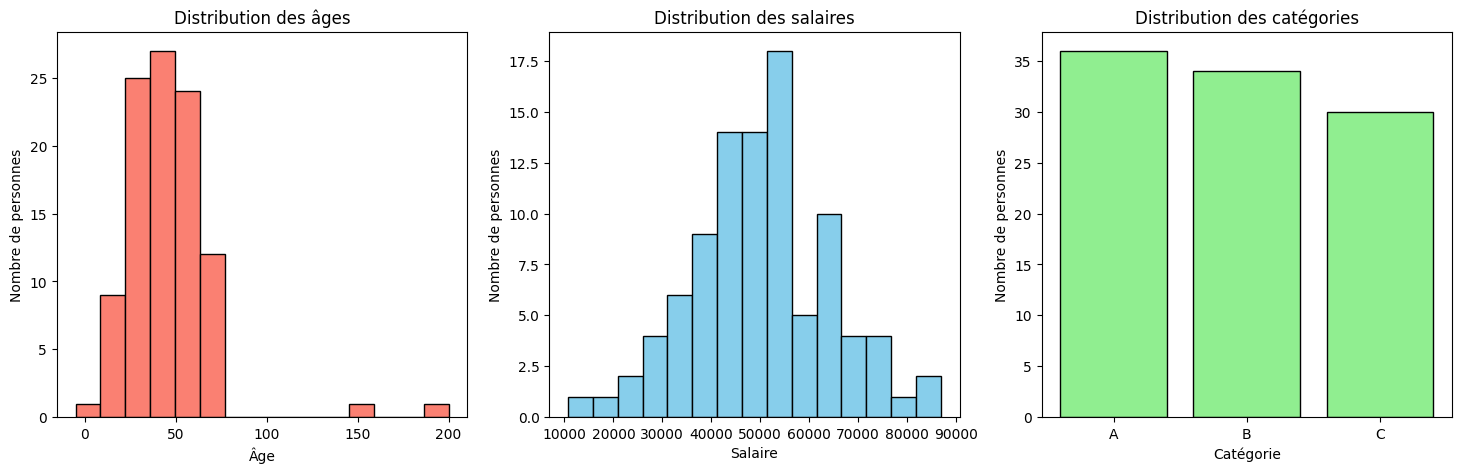

In [30]:
fig

Normalement, mettre toute les histograme dans une seule cellule après fig, axes.
et afficher avec :

plt.tight_layout()  # Ajuste automatiquement l’espacement entre les graphiques

plt.show()          # Affiche la figure complète

#### 3️⃣ Ajouter un boxplot pour voir les outliers

**Lecture d'un boxplot :**
- Boîte = Q1 à Q3 (50% des données)
- Ligne centrale = Médiane
- Moustaches = 1.5 × IQR
- Points = Outliers

Le boxplot est suffisant pour un diagnostic rapide, mais si ton analyse exige une détection basée sur la moyenne et l’écart-type, il faut calculer les z-scores à la main.

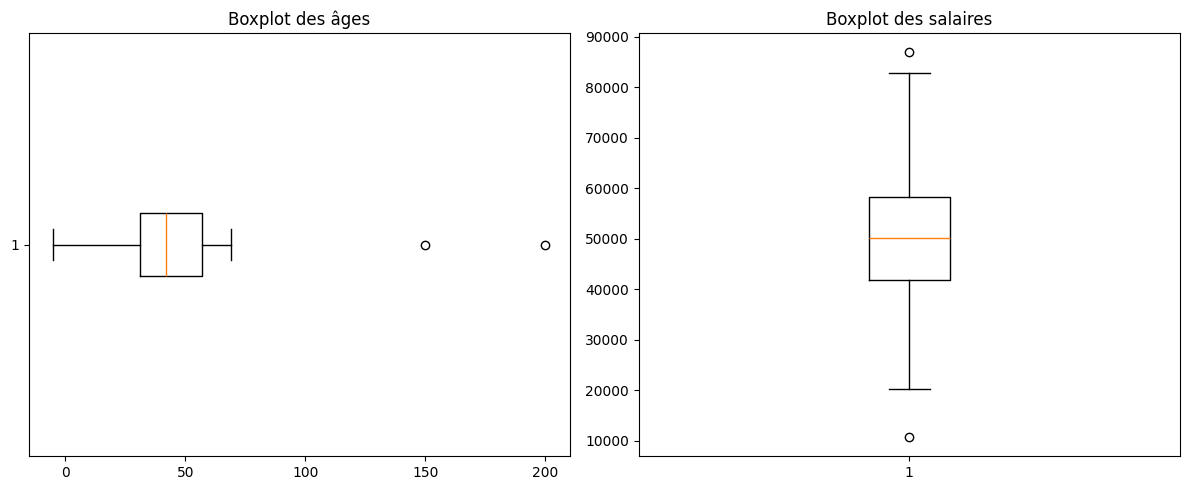

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot simple

# Visualisation des outliers pour les âges
axes[0].boxplot(df_viz['age'].dropna(), vert=False)
axes[0].set_title('Boxplot des âges')

# Visualition des outliers pour les salaires
axes[1].boxplot(df_viz['salaire'].dropna())
axes[1].set_title('Boxplot des salaires')

plt.tight_layout()
plt.show()

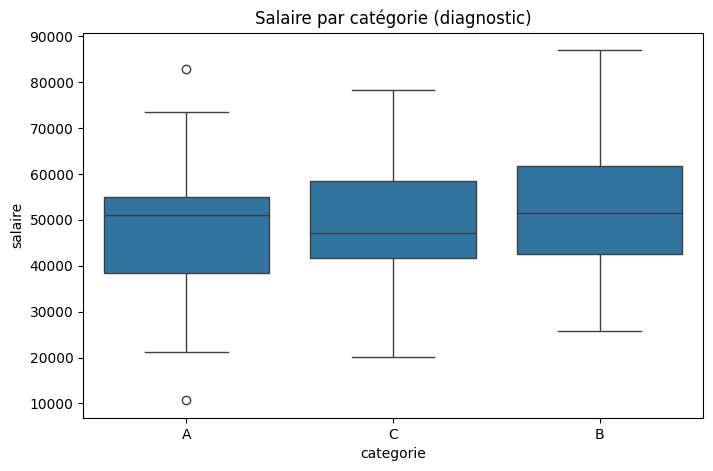

In [32]:
# Boxplot (outliers par catégorie) 
# avec seaborn pour plus de simplicité et de fonctionnalités avancées.
# Visualise les outliers et les valeurs manquantes (NaN apparaissent comme absents).
# Très utile pour comparer des distributions entre catégories.

plt.figure(figsize=(8,5))
sns.boxplot(x='categorie', y='salaire', data=df_viz)
plt.title('Salaire par catégorie (diagnostic)')
plt.show()

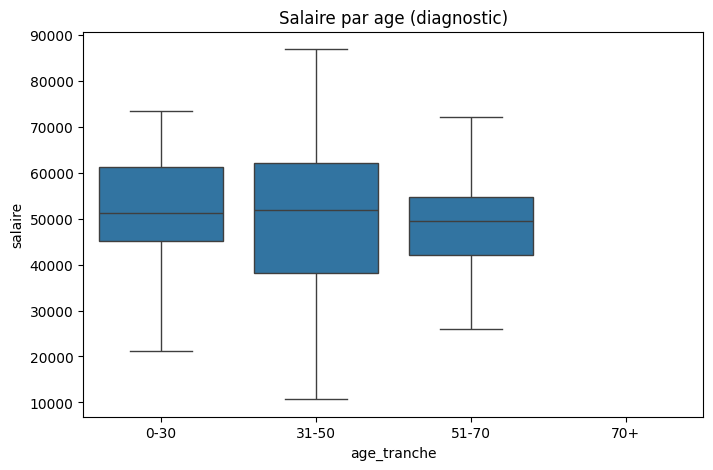

In [42]:
# Boxplot (outliers par âge) 
# avec seaborn pour plus de simplicité et de fonctionnalités avancées.
# Visualise les outliers et les valeurs manquantes (NaN apparaissent comme absents).
# Très utile pour comparer des distributions entre catégories.

# Définir les tranches d'âge
bins = [0, 30, 50, 70, 200]  # bornes des tranches
labels = ['0-30', '31-50', '51-70', '70+']

df_viz['age_tranche'] = pd.cut(df_viz['age'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
sns.boxplot(x='age_tranche', y='salaire', data=df_viz)
plt.title('Salaire par age (diagnostic)')
plt.show()

***Workflow résumé***

- 1.	Boxplot → voir les distributions et outliers
- 2.	Décider si tu veux filtrer ou garder les outliers
- 3.	IQR ou Z-score → filtrer ou supprimer selon le contexte et la distribution
- 4.	Continuer l’analyse ou la visualisation sur le dataset nettoyé

#### 4️⃣ Ajouter un scatter plot pour voir la relation âge vs salaire

1️⃣ Définition
-	Un scatterplot (ou nuage de points) représente deux variables numériques sur un graphique à deux dimensions.
-	Chaque point correspond à une observation :
	-	axe X → variable 1
	-	axe Y → variable 2

2️⃣ Objectifs principaux
1.	Observer la relation entre deux variables numériques
	- 	Positive : les points montent ensemble
	- 	Négative : les points descendent ensemble
	-	Pas de relation : points dispersés
2.	Identifier des clusters / groupes
	-	On peut colorer les points selon une catégorie pour voir des regroupements
3.	Détecter des outliers
	-	Points isolés du nuage → anomalies dans les deux variables


3️⃣ Quand l’utiliser
-	Analyse exploratoire : voir si une variable influence l’autre
-	Diagnostic de données : détecter valeurs aberrantes conjointes
-	Visualisation par catégorie : observer des différences entre groupes

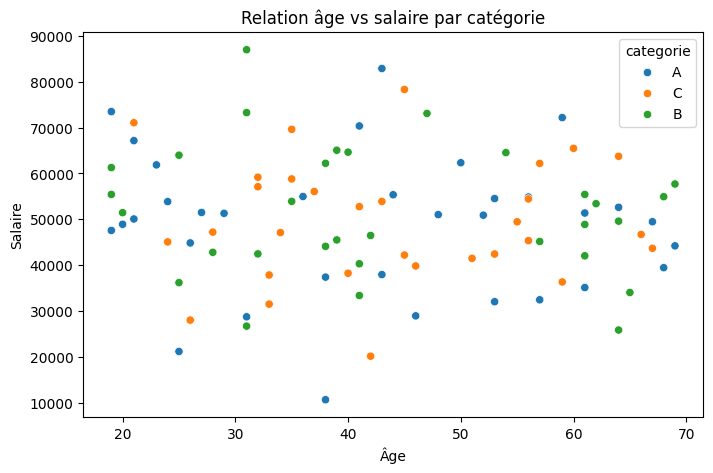

In [33]:
# Créer figure et axe
fig, ax = plt.subplots(figsize=(8,5))

# Scatterplot sur l'axe créé
sns.scatterplot(x='age', y='salaire', hue='categorie', data=df_viz, ax=ax)

# Titres et labels
ax.set_title("Relation âge vs salaire par catégorie")
ax.set_xlabel("Âge")
ax.set_ylabel("Salaire")

# Afficher le graphique
plt.show()

# x='age', y='salaire' → axes numériques
# hue='categorie' → couleur des points selon la catégorie
# Résultat : tu peux voir tendances, outliers et clusters par catégorie

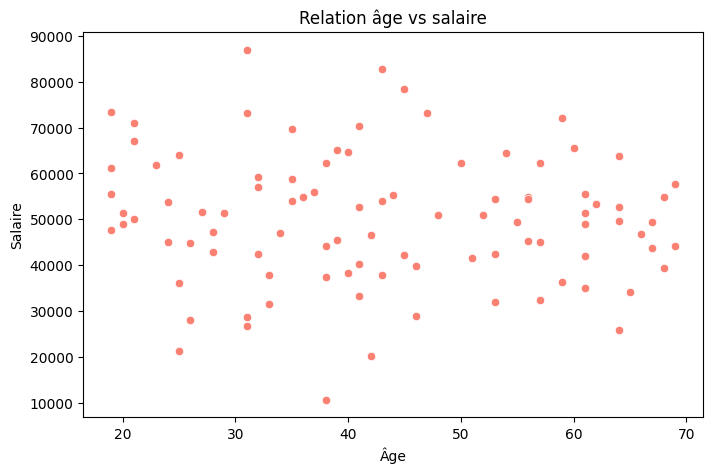

In [34]:
# Créer figure et axe
fig, ax = plt.subplots(figsize=(8,5))

# Scatterplot sur l'axe créé
sns.scatterplot(x='age', y='salaire', data=df_viz, color='salmon', ax=ax)

# Titres et labels
ax.set_title("Relation âge vs salaire")
ax.set_xlabel("Âge")
ax.set_ylabel("Salaire")

# Afficher le graphique
plt.show()

# x='age', y='salaire' → axes numériques
# hue='categorie' → couleur des points selon la catégorie
# Résultat : tu peux voir tendances, outliers et clusters par catégorie

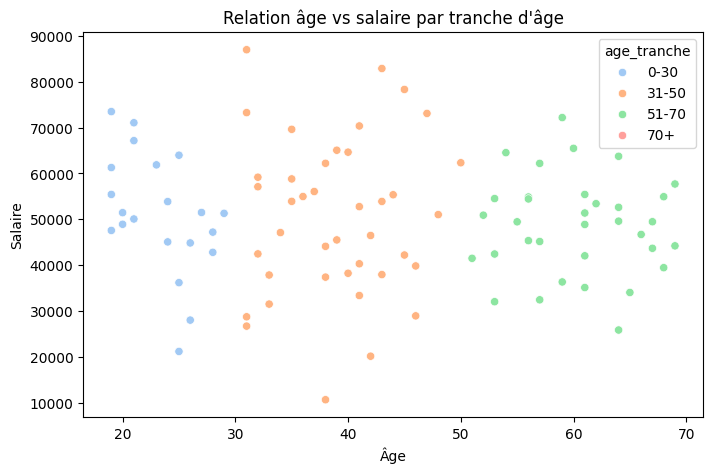

In [35]:
# Préparer les données pour la visualisation par tranches d'âge

# Définir les tranches d'âge
bins = [0, 30, 50, 70, 200]  # bornes des tranches
labels = ['0-30', '31-50', '51-70', '70+']

df_viz['age_tranche'] = pd.cut(df_viz['age'], bins=bins, labels=labels)

# pd.cut → découpe une variable numérique en catégories
# bins → limites des tranches
# labels → nom de chaque tranche

# Créer figure et axe
fig, ax = plt.subplots(figsize=(8,5))

# Scatterplot sur l'axe créé avec tranches d'âge
sns.scatterplot(
    x='age', 
    y='salaire', 
    hue='age_tranche',        # couleur selon la tranche
    data=df_viz, 
    palette='pastel', 
    ax=ax
)

# Titres et labels
ax.set_title("Relation âge vs salaire par tranche d'âge")
ax.set_xlabel("Âge")
ax.set_ylabel("Salaire")

# Afficher le graphique
plt.show()

Analyse des graphiques
1.	Tendances générales :
    -	La majorité des âges se situent entre 18 et 70 ans
    -	La relation âge vs salaire semble largement dispersée, pas de corrélation très nette
2.	Par catégorie :
    -	Les catégories A, B et C se superposent beaucoup
    -	Pas de séparation évidente entre catégories pour salaire → les catégories n’expliquent pas directement la variation de salaire
3.	Par tranche d’âge :
    -	Les jeunes (0-30) et les seniors (51-70) sont bien visibles
    -	Les tranches montrent que les salaires sont plutôt concentrés dans une plage centrale, avec quelques valeurs aberrantes

#### 5️⃣ Heatmap pour les valeurs manquantes

1️⃣ Objectif
-	Identifier rapidement où les données sont manquantes (NaN) dans un dataset.
-	Utile pour :
    -	Vérifier la qualité des données avant analyse
    -	Voir si certaines colonnes ont beaucoup de valeurs manquantes
    -	Détecter des patterns : par exemple, des lignes ou colonnes spécifiques toujours vides

2️⃣ Fonctionnement
-	Chaque case de la heatmap correspond à une cellule dans le dataframe :
-	Couleur claire → donnée présente
-	Couleur sombre → donnée manquante
-	On peut le faire avec seaborn.heatmap() sur le masque des valeurs manquantes.

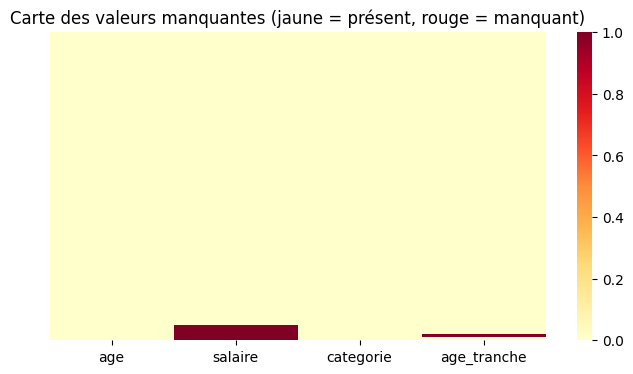

In [36]:
# Visualisation des valeurs manquantes avec une heatmap
fig, ax = plt.subplots(figsize=(8,4))

# Créer le masque : True si valeur manquante
missing_matrice = df_viz.isnull()  # → dataframe booléen (True si NaN)

# Heatmap
sns.heatmap(missing_matrice, cbar=True, yticklabels=False, cmap='YlOrRd')
ax.set_title('Carte des valeurs manquantes (jaune = présent, rouge = manquant)')
plt.show()

# sns.heatmap(..., cmap='viridis') → couleur pour visualiser les données manquantes
# yticklabels=False → pas d’étiquettes sur l’axe Y
# cbar=True → afficher la barre de couleur

Analyse sur ton dataset
-	La colonne salaire contient quelques NaN → visibles sur la heatmap
-	age et categorie sont complètes sauf anomalies extrêmes
-	Heatmap permet de voir d’un coup d’œil si certaines colonnes ou lignes sont problématiques

💡 Astuce :
On utilise ce type de heatmap pour un diagnostic rapide, avant toute statistique ou modélisation, afin de savoir quelles colonnes nécessitent un nettoyage ou un imputation.

Dataset exemple :
    age  salaire categorie
0  25.0  50000.0         A
1  30.0      NaN         B
2   NaN  60000.0         A
3  45.0  70000.0      None
4  50.0      NaN         C
5   NaN  80000.0         B


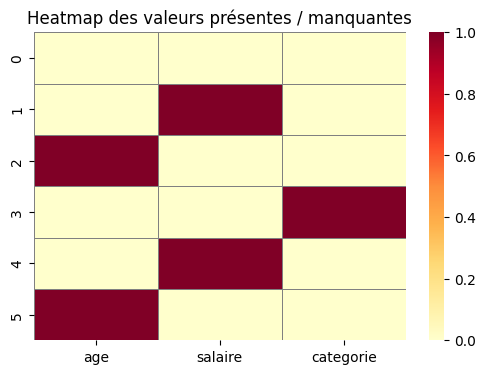

In [43]:
# Créer un petit dataset exemple
data = {
    'age': [25, 30, None, 45, 50, None],
    'salaire': [50000, None, 60000, 70000, None, 80000],
    'categorie': ['A', 'B', 'A', None, 'C', 'B']
}

df_example = pd.DataFrame(data)

print("Dataset exemple :")
print(df_example)

# Créer la figure
fig, ax = plt.subplots(figsize=(6,4))

# Créer le masque des valeurs manquantes
missing_matrice = df_example.isna()

# Heatmap : True = valeur présente, False = manquante
sns.heatmap(missing_matrice, cmap='YlOrRd', cbar=True, ax=ax, linewidths=0.5, linecolor='gray')
ax.set_title("Heatmap des valeurs présentes / manquantes")
plt.show()

### ✍️ Exercice 4.8 : Dashboard de diagnostic (20 min)

Créez un dashboard de diagnostic complet pour un DataFrame :

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Données simulées
np.random.seed(42)
n = 1000
df_dashboard = pd.DataFrame({
    'age': np.concatenate([np.random.randint(18, 70, 997), [150, -5, 200]]),
    'revenu': np.concatenate([np.random.normal(50000, 15000, 900), [np.nan]*100]),
    'categorie': np.random.choice(['A', 'B', 'C', None], 1000, p=[0.3, 0.3, 0.3, 0.1])
})

print("Données créées pour le dashboard")
print(f"Shape : {df_dashboard.shape}")

Données créées pour le dashboard
Shape : (1000, 3)


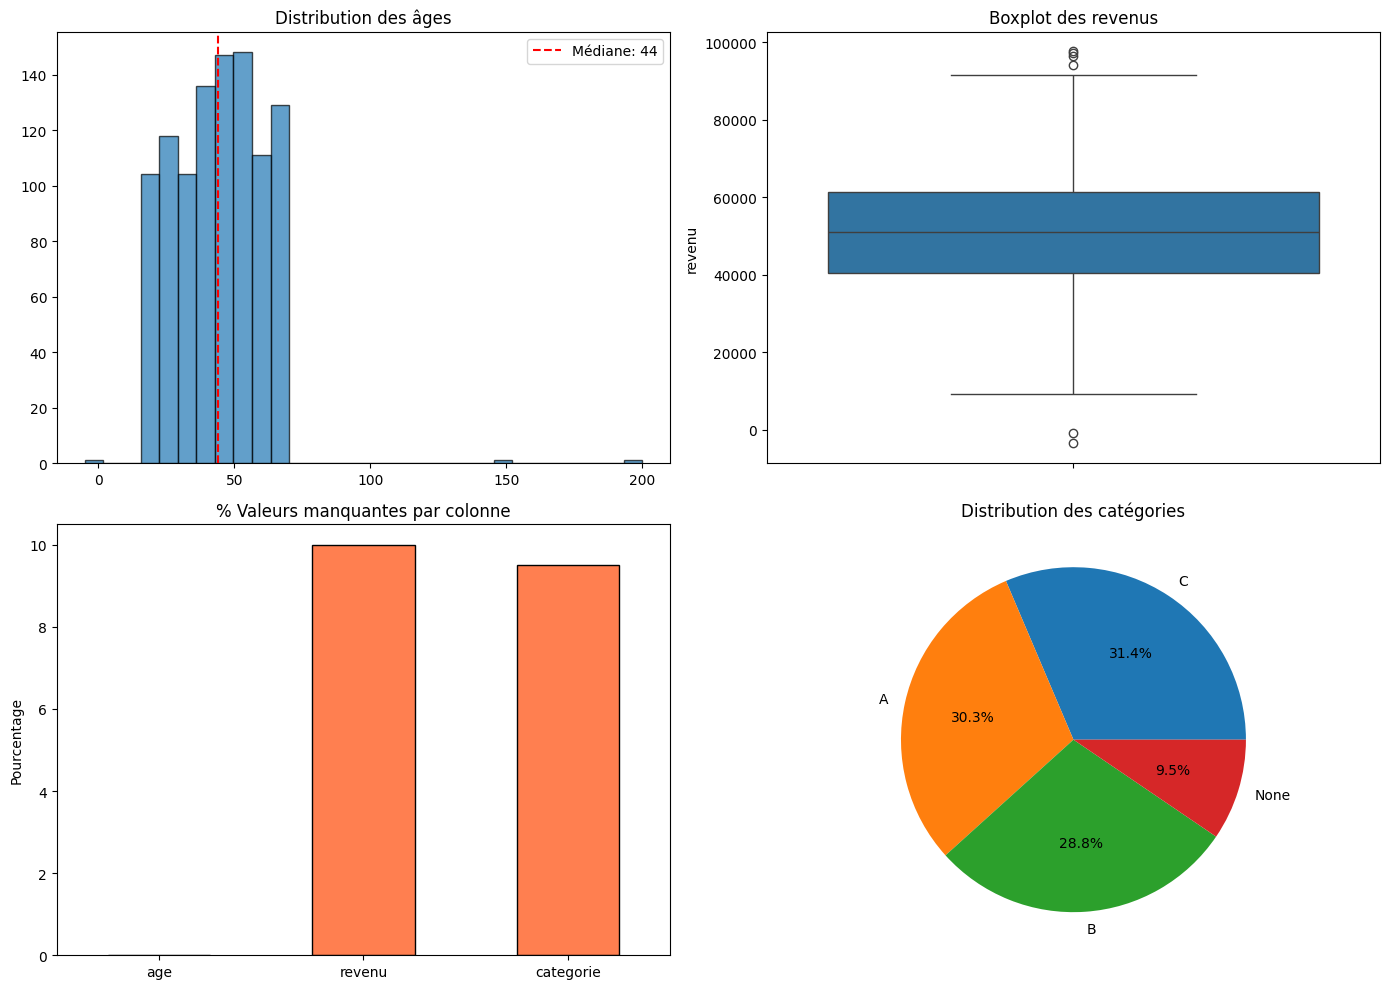

In [39]:
# Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution des âges avec outliers
axes[0, 0].hist(df_dashboard['age'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution des âges')
axes[0, 0].axvline(df_dashboard['age'].median(), color='red', linestyle='--', label=f'Médiane: {df_dashboard["age"].median():.0f}')
axes[0, 0].legend()

# 2. Boxplot des revenus
sns.boxplot(y=df_dashboard['revenu'].dropna(), ax=axes[0, 1])
axes[0, 1].set_title('Boxplot des revenus')

# 3. Valeurs manquantes par colonne
missing_pct = (df_dashboard.isnull().mean() * 100)
missing_pct.plot(kind='bar', ax=axes[1, 0], color='coral', edgecolor='black')
axes[1, 0].set_title('% Valeurs manquantes par colonne')
axes[1, 0].set_ylabel('Pourcentage')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

# 4. Distribution des catégories
cat_counts = df_dashboard['categorie'].value_counts(dropna=False)
cat_counts.plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%')
axes[1, 1].set_title('Distribution des catégories')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

In [40]:
# Questions du dashboard :
print("--- Analyse du Dashboard ---")

# 1. Combien d'outliers identifiez-vous dans les âges ?
outliers_age = df_dashboard[(df_dashboard['age'] < 0) | (df_dashboard['age'] > 120)]
print(f"\n1. Outliers dans les âges : {len(outliers_age)}")
print(f"   Valeurs : {outliers_age['age'].values}")

# 2. Quel pourcentage de revenus est manquant ?
pct_revenu_missing = df_dashboard['revenu'].isnull().mean() * 100
print(f"\n2. Revenus manquants : {pct_revenu_missing:.1f}%")

# 3. Quel problème voyez-vous dans les catégories ?
pct_cat_missing = df_dashboard['categorie'].isnull().mean() * 100
print(f"\n3. Problème catégories : {pct_cat_missing:.1f}% de valeurs manquantes (None)")

--- Analyse du Dashboard ---

1. Outliers dans les âges : 3
   Valeurs : [150  -5 200]

2. Revenus manquants : 10.0%

3. Problème catégories : 9.5% de valeurs manquantes (None)
